# Beam-convolved foreground eigenmodes

SVD of the EIGSEP baseline zenith-drift waterfall, quantifying how
many spectral modes describe the beam-convolved foregrounds.

The data (`foreground_svd.npz`) is the system temperature `t_sys`
(`n_time` x `n_freq`) for a fixed zenith-pointing antenna over one
sidereal day: bowtie beam, GSM16 sky, `T_ground = 300` K,
`T_receiver = 50` K, realistic horizon. We subtract the constant
receiver temperature to form the antenna temperature (which still
includes the LST-invariant ground pickup) and take the SVD of the
(uncentered) antenna-temperature time-frequency waterfall.
Each singular value $s_i$ is reported as a per-channel RMS temperature $s_i / \sqrt{n_{\rm time}\,n_{\rm freq}}$ [K], and the residual after projecting out the leading $N$ modes is $\sqrt{\sum_{i>N} s_i^2 / (n_{\rm time}\,n_{\rm freq})}$.

In [7]:
import numpy as np
import matplotlib.pyplot as plt

In [8]:
def load_data(fname="foreground_svd.npz"):
    d = np.load(fname)
    t_ant = d["t_sys"] - d["t_receiver"]  # antenna temperature (drop const receiver)
    return d["freqs_MHz"], t_ant


freqs, t_ant = load_data()
n_t, n_f = t_ant.shape
print(f"waterfall: {n_t} LST x {n_f} freq, {freqs[0]:.0f}-{freqs[-1]:.0f} MHz")

waterfall: 1436 LST x 201 freq, 50-250 MHz


In [9]:
s = np.linalg.svd(t_ant, compute_uv=False)
norm = np.sqrt(n_t * n_f)
rms_K = s / norm  # per-mode per-channel RMS

# residual RMS after projecting out the leading N modes [K]
tail = np.concatenate([np.cumsum(s[::-1] ** 2)[::-1], [0.0]])
resid_K = np.sqrt(tail / (n_t * n_f))

N_SHOW = 25

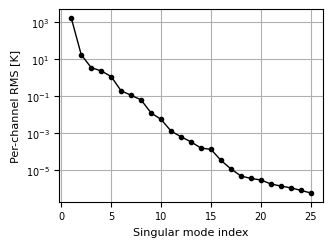

In [10]:
def plot_spectrum(rms_K, save=False, save_path="foreground_svd_spectrum.pdf"):
    modes = np.arange(1, N_SHOW + 1)
    plt.figure(figsize=(3.4, 2.5))
    plt.plot(modes, rms_K[:N_SHOW], "o-", c="k", ms=3, lw=1)
    plt.xlabel("Singular mode index", fontsize=8)
    plt.ylabel("Per-channel RMS [K]", fontsize=8)
    plt.yscale("log")
    plt.grid()
    plt.xticks(fontsize=7)
    plt.yticks(fontsize=7)
    if save:
        plt.savefig(save_path, bbox_inches="tight", dpi=600)


plot_spectrum(rms_K, save=False)

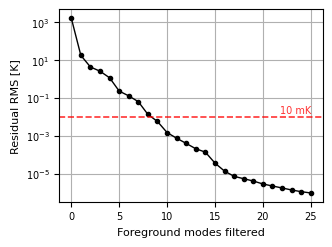

In [21]:
def plot_residual(resid_K, save=False, save_path="foreground_svd_residual.pdf"):
    n_removed = np.arange(N_SHOW + 1)
    plt.figure(figsize=(3.4, 2.5))
    plt.plot(n_removed, resid_K[: N_SHOW + 1], "o-", c="k", ms=3, lw=1)
    plt.axhline(1e-2, c="red", lw=1.2, ls="--", alpha=0.8)
    plt.text(N_SHOW, 1.15e-2, "10 mK", c="red", alpha=0.8,
             fontsize=7, va="bottom", ha="right")
    plt.xlabel("Foreground modes filtered", fontsize=8)
    plt.ylabel("Residual RMS [K]", fontsize=8)
    plt.yscale("log")
    plt.grid()
    plt.xticks(fontsize=7)
    plt.yticks(fontsize=7)
    if save:
        plt.savefig(save_path, bbox_inches="tight", dpi=600)


plot_residual(resid_K, save=True)

In [20]:
resid_K[5]

np.float64(0.22658072216733857)

In [14]:
n_below = int(np.nonzero(resid_K < 1e-3)[0][0])
print(f"mode 1 per-channel RMS: {rms_K[0]:.1f} K")
print(f"residual after 10 modes: {resid_K[10] * 1e3:.2f} mK")
print(f"modes to reach < 1 mK residual: {n_below}")

mode 1 per-channel RMS: 1621.5 K
residual after 10 modes: 1.47 mK
modes to reach < 1 mK residual: 11
